In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Lecture des données
X_train = pd.read_csv("../data/X_train_update.csv")
y_train = pd.read_csv("../data/Y_train_CVw08PX.csv")
X_test = pd.read_csv("../data/X_test_update.csv")

# Affichage des informations sur les datasets
print(f"Info X_train : {X_train.info()}")
print(f"Info Y_train : {y_train.info()}")
print(f"Info X_test : {X_test.info()}")

# Affichage des tailles des datasets
print(f"Taille X_train : {X_train.shape}")
print(f"Taille Y_train : {y_train.shape}")
print(f"Taille X_test : {X_test.shape}")

# Affichage du nombre de classes dans la variable cible
print(y_train['prdtypecode'].nunique())  # 27 classes

# Merge données d'entrainement
full_data = pd.merge(X_train, y_train, left_index=True, right_index=True)

# Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

# Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)
full_data.set_index(['id'], inplace=True)

X_test.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
X_test.set_index(['id'], inplace=True)

#Longueur des textes
full_data['len_designation'] = (full_data['designation'].astype(str).apply(len))
full_data['len_description'] = (full_data['description'].astype(str).apply(len))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.2+ MB
Info X_train : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   84916 non-null  int64
 1   prdtypecode  84916 non-null  int64
dtypes: int64(2)
memory usage: 1.3 MB
Info Y_train : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   1

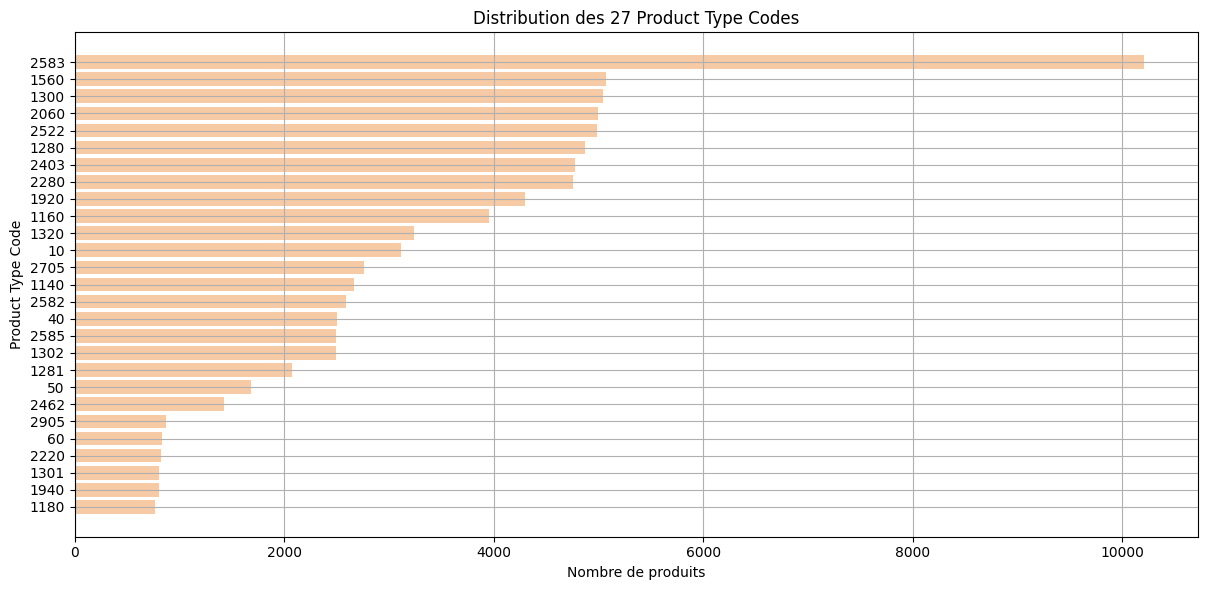

In [23]:
# Affichage du nombre de classes dans la variable cible
plt.figure(figsize=(12,6))
class_dist = y_train['prdtypecode'].value_counts().sort_values(ascending=True)

# Affichage de la distribution des classes avec chaque barre représentant une classe et sa hauteur représentant le nombre d'exemples dans cette classe
plt.barh(range(len(class_dist)), class_dist.values, color='#F6CAA4')
plt.title('Distribution des 27 Product Type Codes')
plt.xlabel('Nombre de produits') # Affichage du nombre de produits sur l'axe x
plt.ylabel('Product Type Code') # Affichage des codes de produits sur l'axe y
plt.tight_layout()
plt.grid()
plt.yticks(range(len(class_dist)), class_dist.index) # Affichage des codes de produits sur l'axe x
plt.show()

# Classes rares < 100 exemples vs classes fréquentes > 10k exemples -> risque de biais vers les classes majoritaires

C:\Users\Yacinou\AppData\Local\Temp\ipykernel_28548\2299512070.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=y_train, x='prdtypecode', order=y_train['prdtypecode'].value_counts().index, palette='managua')


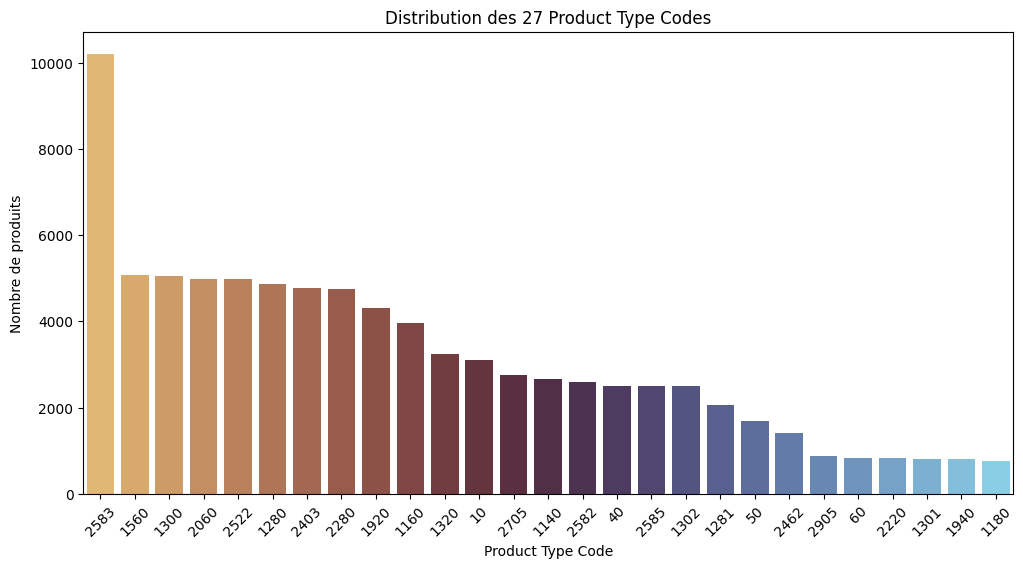

In [33]:
# Affichage de la distribution des classes avec seaborn

plt.figure(figsize=(12,6))
sns.countplot(data=y_train, x='prdtypecode', order=y_train['prdtypecode'].value_counts().index, palette='managua')
plt.title('Distribution des 27 Product Type Codes')
plt.xlabel('Product Type Code') # Affichage des codes de produits sur l'axe x
plt.ylabel('Nombre de produits') # Affichage du nombre de produits sur l'axe y
plt.xticks(rotation=45)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yacinou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


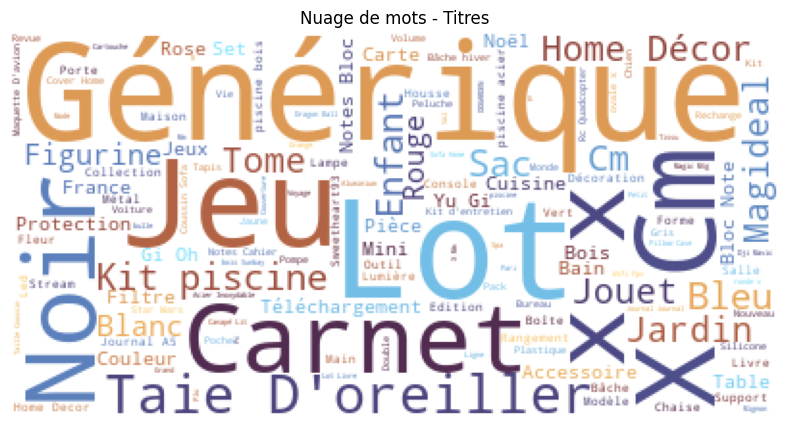

In [34]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Nuage de mots pour les titres
plt.figure(figsize=(8,8))
nltk.download('stopwords')
stop_words = set(stopwords.words('french') + stopwords.words('english') + stopwords.words('german'))
text = ' '.join(X_train['designation'].dropna())
wc = WordCloud(colormap='managua', background_color='white',stopwords=stop_words).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.title("Nuage de mots - Titres")
plt.tight_layout()
plt.show()

# Mot clés métiers dominants
# Validation : TF-IDF top 10 vs classes -> corrélation de pearson > 0.8 avec prdtypecode -> on peut conclure que les mots clés métiers sont de bons indicateurs pour différencier les classes de produits

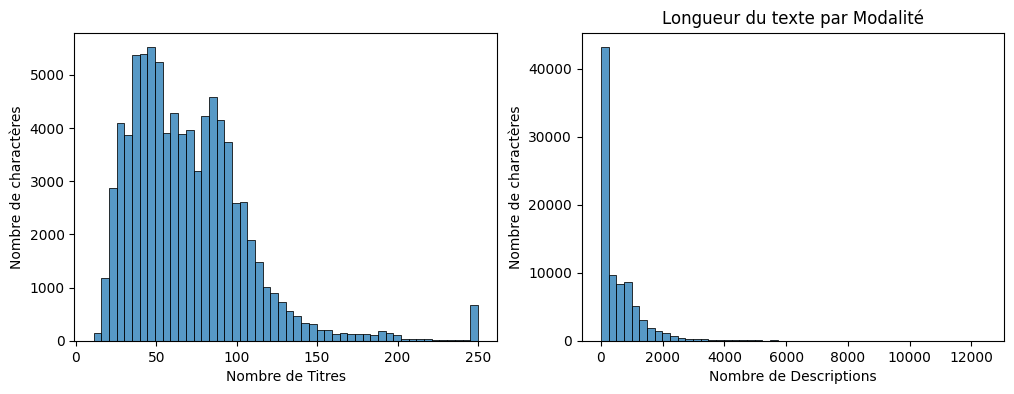

In [5]:
X_train['title_len'] = X_train['designation'].str.len()
X_train['desc_len'] = X_train['description'].fillna('').str.len()
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
tit = sns.histplot(X_train['title_len'], bins=50, ax=ax1, label='Longueur de titre')
tit.set(xlabel='Nombre de Titres', ylabel='Nombre de charactères')
des = sns.histplot(X_train['desc_len'], bins=50, ax=ax2, label='Longueur de description')
des.set(xlabel='Nombre de Descriptions', ylabel='Nombre de charactères')
plt.title('Longueur du texte par Modalité')
plt.show()

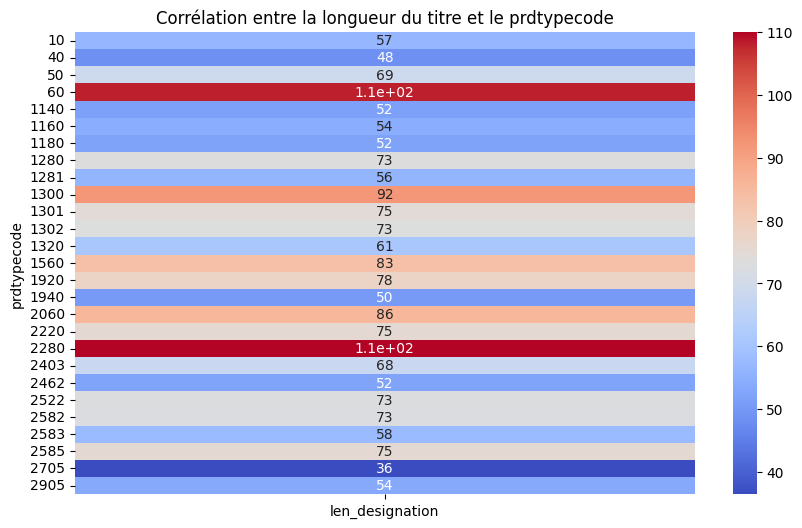

In [ ]:
# Heatmap corrélation longueur du titre vs prdtypecode 
plt.figure(figsize=(10,6))
pivot = full_data.pivot_table(index='prdtypecode', values='len_designation', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Corrélation entre la longueur du titre et le prdtypecode')
plt.show()

# Corrélation de pearson < 0.2 -> on peut conclure que la longueur du texte n'est pas un bon indicateur pour différencier les classes de produits